O autor utilizou o AI Asssitant da IDE PyCharm 2025.3.4 e a LLM Gemini 3.1 Pro para debugar

In [1]:
import math
import os
from pathlib import Path

import PIL
import matplotlib.pyplot as plt #3.10.8
import matplotlib.image as imread
import seaborn as sns #0.13.2
import numpy as np #2.4.4
import pandas as pd #3.0.2
from PIL import Image #12.1.1


In [2]:
# Config dataset
TRAIN_PATH = Path('train')
TEST_PATH = Path('test')
LABELS_TRAIN_PATH = Path('labels', 'train_gabarito.csv')

Tamanho do dataset e distribuição de classes

In [3]:
files_train_gen = TRAIN_PATH.glob('*.*')
files_train_path_list = [file for file in files_train_gen]

files_test_gen = TEST_PATH.glob('*.*')
files_test_path_list = [file for file in files_test_gen]

print(f'Training size: {len(files_train_path_list)}')
print(f'Testing size: {len(files_test_path_list)}')

Training size: 279
Testing size: 70


In [4]:
labels_train_df = pd.read_csv(LABELS_TRAIN_PATH)
labels_train_df.head()


,Nome,Label
0,Good_good_tomato (28).jpg,1
1,Bad_bad_tomato (104).jpg,0
2,Bad_bad_tomato (1).jpg,0
3,Good_good_tomato (112).jpg,1
4,Good_good_tomato (126).jpg,1


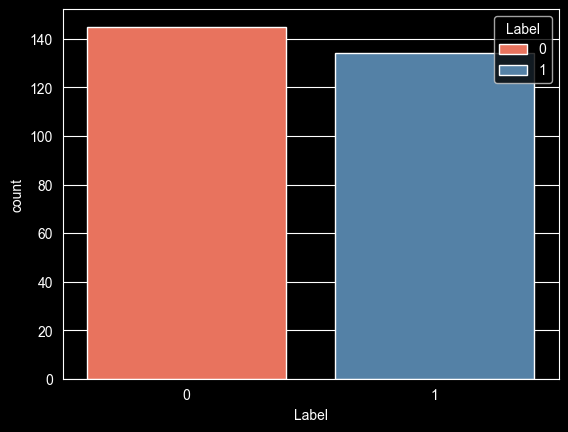

In [5]:
_ = sns.countplot(data=labels_train_df, x ='Label', hue='Label', palette={0: 'tomato', 1: 'steelblue'})
plt.show()

In [6]:
labels_train_df.value_counts(["Label"], normalize=True)

Label
0        0.519713
1        0.480287
Name: proportion, dtype: float64

Checks de sanidade

In [7]:
class SanityChecks:
    def __init__(self, path: Path) -> None:
        self.path = path
        self.files_list = self.__get_path_list()
        self.mode_types = []
        self.width = []
        self.height = []

    def __get_path_list(self) -> list:
        files_path_gen = self.path.glob('*.*')
        return [file for file in files_path_gen]

    def check_corruption(self) -> dict:
        error = []
        for file in self.files_list:
            try:
                img = Image.open(file)
                self.mode_types.append(img.mode)
                self.width.append(img.width)
                self.height.append(img.height)
            except:
                error.append(file)
        return {
            'qt_errors': len(error), 'files_erros': error}

    def check_typing(self) -> dict:
        print(self.files_list[0])
        ext = [str(file).split('.')[-1] for file in self.files_list]
        return {
            "ext": list(set(ext))
        }
    def check_mode(self) -> dict:
        return {
            'modes': list(set(self.mode_types))
        }

    def check_dimensions (self) -> dict:
        return {
            'width': list(set(self.width)),
            'height': list(set(self.height))
        }

In [8]:
sanity_checks = SanityChecks(TRAIN_PATH)
print(sanity_checks.check_corruption())
print(sanity_checks.check_typing())
print(sanity_checks.check_mode())
print(sanity_checks.check_dimensions())

{'qt_errors': 0, 'files_erros': []}
train\Bad_bad_tomato (1).jpg
{'ext': ['jpg']}
{'modes': ['L']}
{'width': [224], 'height': [224]}


In [9]:
sanity_checks = SanityChecks(TEST_PATH)
print(sanity_checks.check_corruption())
print(sanity_checks.check_typing())
print(sanity_checks.check_mode())
print(sanity_checks.check_dimensions())

{'qt_errors': 0, 'files_erros': []}
test\Bad_bad_tomato (10).jpg
{'ext': ['jpg']}
{'modes': ['L']}
{'width': [224], 'height': [224]}


In [10]:
def plot_images(path: Path, sample_size: int):
    files_path_gen = path.glob('*.*')
    files = [file for file in files_path_gen]

    sample = np.random.choice(files, sample_size)

    cols = math.ceil(math.sqrt(sample_size))
    rows = math.ceil(math.sqrt(sample_size))

    plt.figure(figsize=(10,10))
    plt.suptitle(f'Sample of {sample_size} images from {path}')
    for i, file in enumerate(sample):
        img = Image.open(file)
        plt.subplot(rows, cols, i+1)
        plt.imshow(img, cmap='gray')
        plt.axis('off')

    plt.tight_layout()
    plt.show()

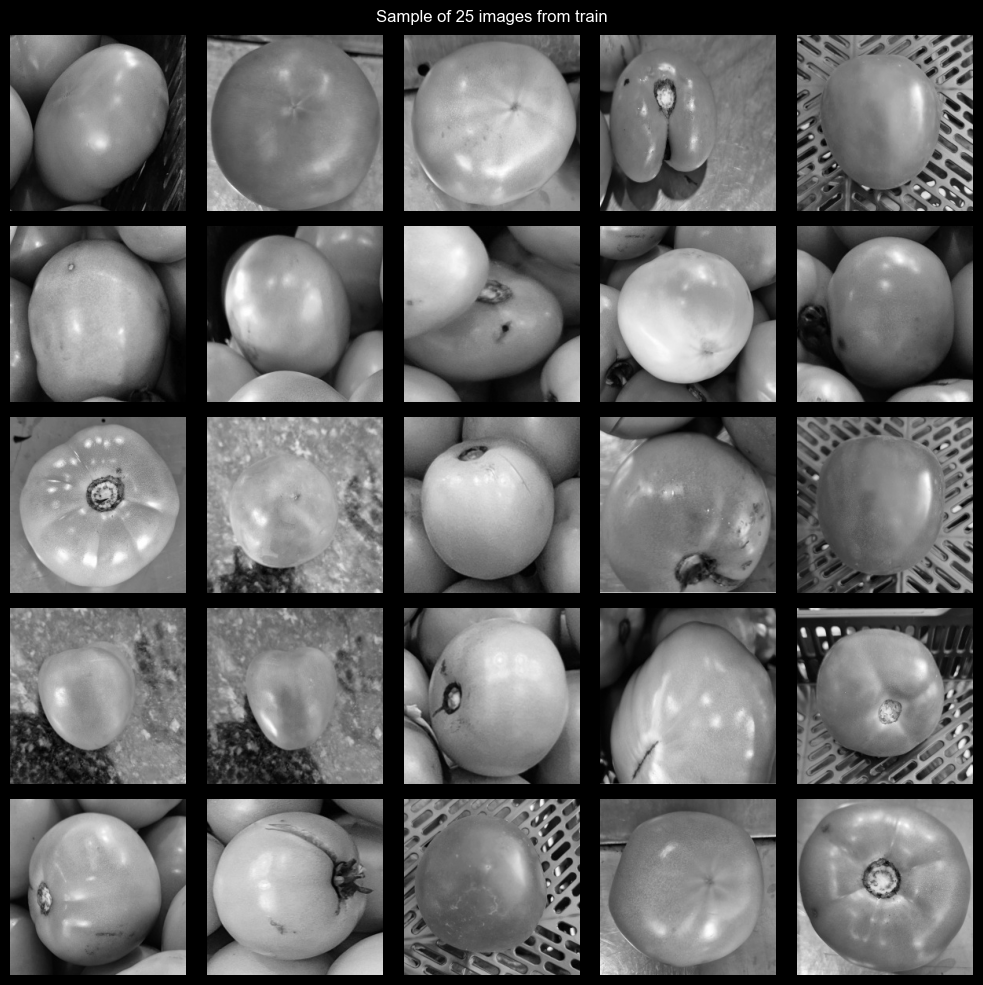

In [11]:
plot_images(TRAIN_PATH, sample_size=25)

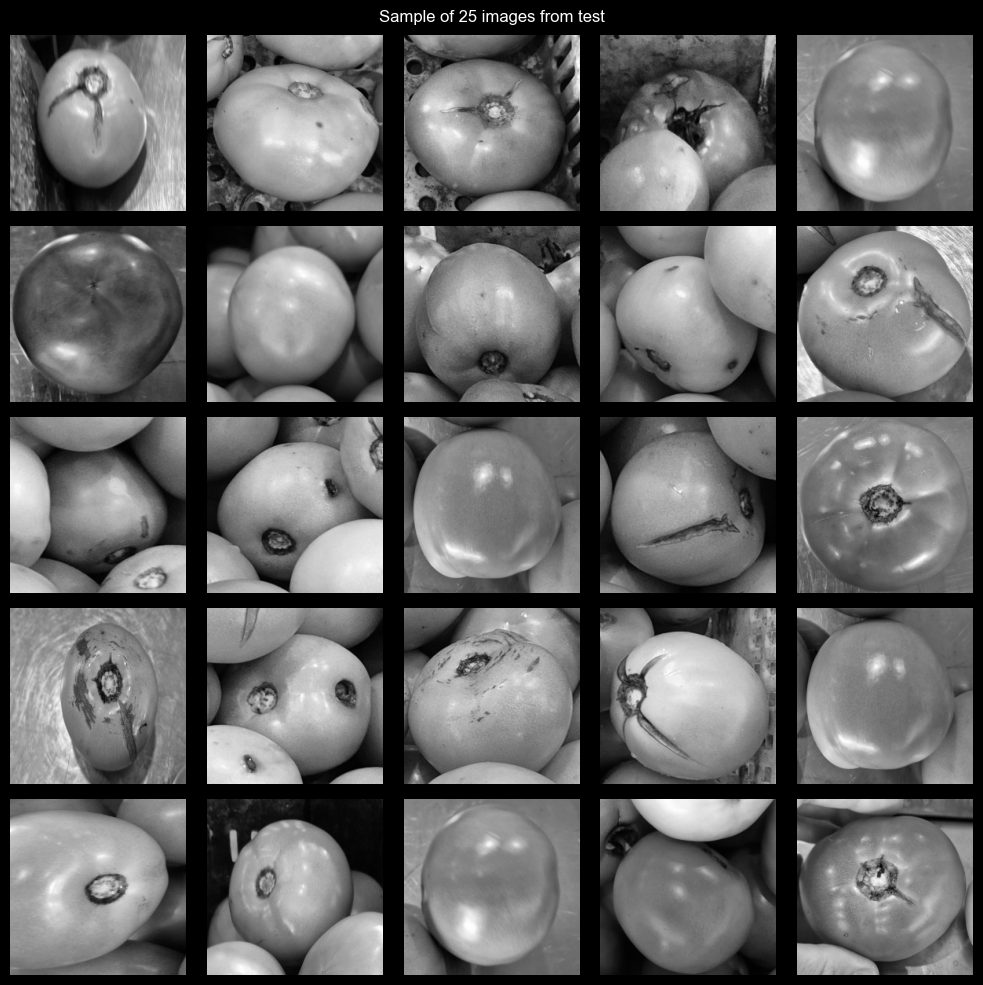

In [12]:
plot_images(TEST_PATH, sample_size=25)

Visualizando a distribuição de pixels

In [13]:
class PixelsVerify:
    def __init__(self, path: Path, labels_path: Path) -> None:
        self.train_path = path
        self.files = self.__get_path_list()
        self.labels_train_df = pd.read_csv(labels_path)
        self.sample = []
        self.rows = None
        self.cols = None

        self.labels_map = dict(
            zip(self.labels_train_df["Nome"], self.labels_train_df["Label"])
        )

    def __get_path_list(self) -> list:
        files_path_gen = self.train_path.glob("*.*")
        return [file for file in files_path_gen]

    def __get_grey_pixels(self, image):
        pixels = image.histogram()
        return pixels [:256]

    def plot_histograms(self, sample_size):
        self.sample = np.random.choice(self.files, sample_size)

        # Pair each file with its labels directly
        samples_with_labels = [
            (file, self.labels_map.get(file.name, "unknown"))
            for file in self.sample
        ]

        self.cols = math.ceil(math.sqrt(sample_size))
        self.rows = math.ceil(math.sqrt(sample_size))

        plt.figure(figsize=(10, 10))
        plt.suptitle("Sample of histograms from database")

        for i, (file, label) in enumerate(samples_with_labels):
            img = Image.open(file)
            pixels = self.__get_grey_pixels(img)

            plt.subplot(self.rows, self.cols, i + 1)
            plt.plot(list(range(256)), pixels, color="blue")
            plt.title(f"{file.name} - {label}")

        plt.tight_layout()
        plt.show()
    def plot_imgs_from_histograms(self):
        plt.figure(figsize=(10,10))
        plt.suptitle(f'Imagens aleatórias referentes aos histogramas')
        for i, file in enumerate(self.sample):
            img = Image.open(file)
            plt.subplot(self.rows, self.cols, i+1)
            plt.imshow(img, cmap='gray')
            plt.title(file.name)
            plt.axis('off')

        plt.tight_layout()
        plt.show()


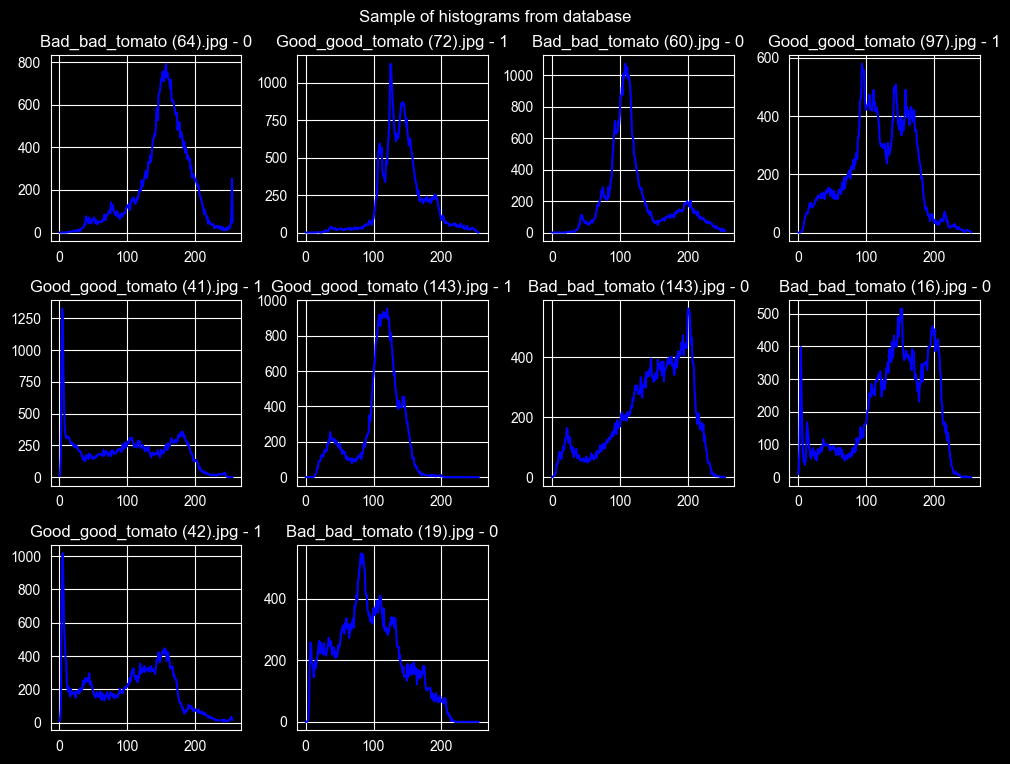

In [14]:
pixels = PixelsVerify(TRAIN_PATH, LABELS_TRAIN_PATH)
pixels.plot_histograms(sample_size=10)

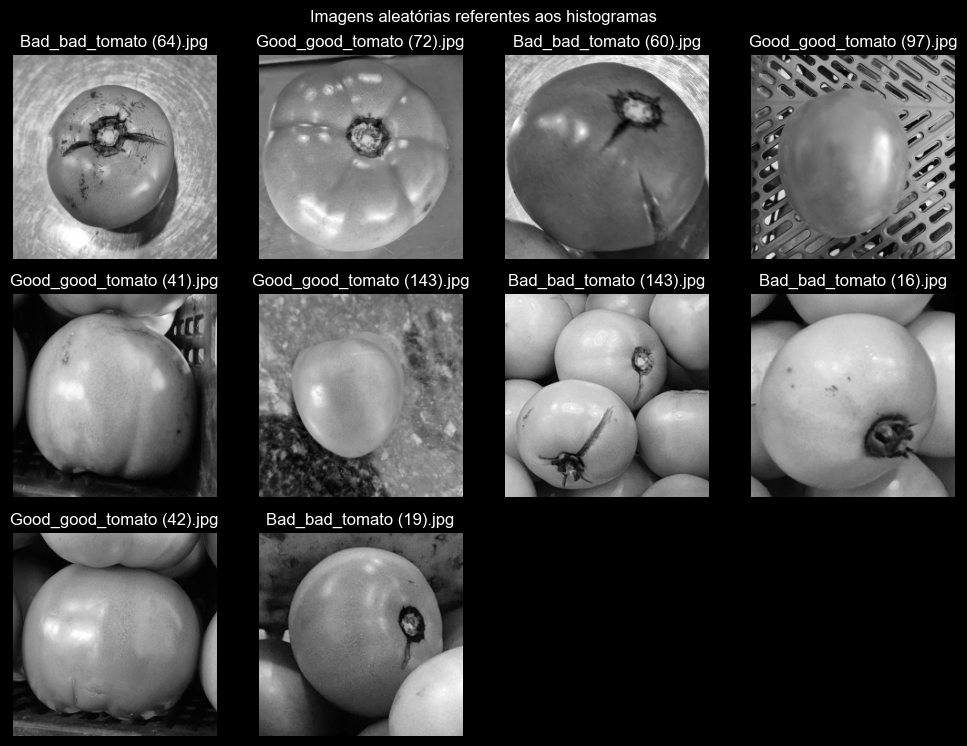

In [15]:
pixels.plot_imgs_from_histograms()